In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import sklearn
from sklearn.preprocessing import StandardScaler
import scipy 
from scipy.stats import nbinom
import seaborn as sns
import warnings
from statsmodels.genmod.families import NegativeBinomial
warnings.filterwarnings("ignore")
from linearmodels.panel import PooledOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
import semopy 
from factor_analyzer import FactorAnalyzer
from IPython.display import Image
import graphviz
from semopy import ModelMeans
from semopy.inspector import inspect
from semopy.stats import calc_stats



%matplotlib inline

# Tarea N3

- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- area: urbana=1, rural=0
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: siempre - 5: nunca)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca) 
- sk10: tiene interes por libros (1: siempre - 5: nunca) 
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca) 
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca) 
- act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

Preguntas:

1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [98]:
url= 'https://raw.githubusercontent.com/juancaros/LAB-MAA/refs/heads/main/data/junaeb3.csv'
df=pd.read_csv(url)
df

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,2,3,2,NaN,0,11.0,11,-1
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
2,1,68,0.27,0,1,2,2,3,2,1,...,2,3,2,1,3,NaN,1,13.0,13,1
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,...,2,2,2,1,1,2.0,1,13.0,13,-1
31051,1,79,2.57,1,1,1,1,2,2,1,...,1,3,2,1,4,3.0,1,18.0,19,0
31052,0,78,2.12,1,1,1,1,1,1,1,...,1,3,1,1,1,3.0,1,13.0,9,1
31053,1,78,-0.43,1,1,1,1,1,1,2,...,1,2,1,1,2,2.0,1,17.0,15,1


In [99]:
print(df.isna().sum())

sexo             0
edad             0
imce             0
vive_padre       0
vive_madre       0
sk1              0
sk2              0
sk3              0
sk4              0
sk5              0
sk6              0
sk7              0
sk8              0
sk9              0
sk10             0
sk11             0
sk12             0
sk13             0
act_fisica    1004
area             0
educm          373
educp            0
madre_work       0
dtype: int64


In [100]:
#Dado que hay pocos NaN en relación a las filas totales de nuestro df, usamos dropna.
df = df.dropna()
df

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,1,1,1,4.0,0,8.0,8,-1
6,1,91,2.75,1,1,1,1,1,2,2,...,3,3,3,2,2,2.0,1,20.0,19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,...,2,2,2,1,1,2.0,1,13.0,13,-1
31051,1,79,2.57,1,1,1,1,2,2,1,...,1,3,2,1,4,3.0,1,18.0,19,0
31052,0,78,2.12,1,1,1,1,1,1,1,...,1,3,1,1,1,3.0,1,13.0,9,1
31053,1,78,-0.43,1,1,1,1,1,1,2,...,1,2,1,1,2,2.0,1,17.0,15,1


In [101]:
df.describe(include='all')


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,29696.000000,29696.000000,29696.00000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,...,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000
mean,0.539164,82.544450,1.01826,0.720097,0.975990,1.108533,1.386651,1.256802,1.250943,1.264749,...,1.326307,1.844693,1.379108,1.495858,1.687298,2.556270,0.911705,13.106311,13.001785,0.106917
std,0.498472,4.295051,1.36947,0.449559,0.164329,0.379168,0.643343,0.575636,0.569647,0.558138,...,0.655108,0.933154,0.660226,0.790316,0.979401,1.067923,0.283728,3.328273,3.418317,0.941629
min,0.000000,62.000000,-5.02000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,80.000000,0.12000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,12.000000,11.000000,-1.000000
50%,1.000000,81.000000,0.98000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,13.000000,13.000000,1.000000
75%,1.000000,82.000000,1.93000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000,15.000000,15.000000,1.000000
max,1.000000,107.000000,5.04000,2.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,22.000000,22.000000,1.000000


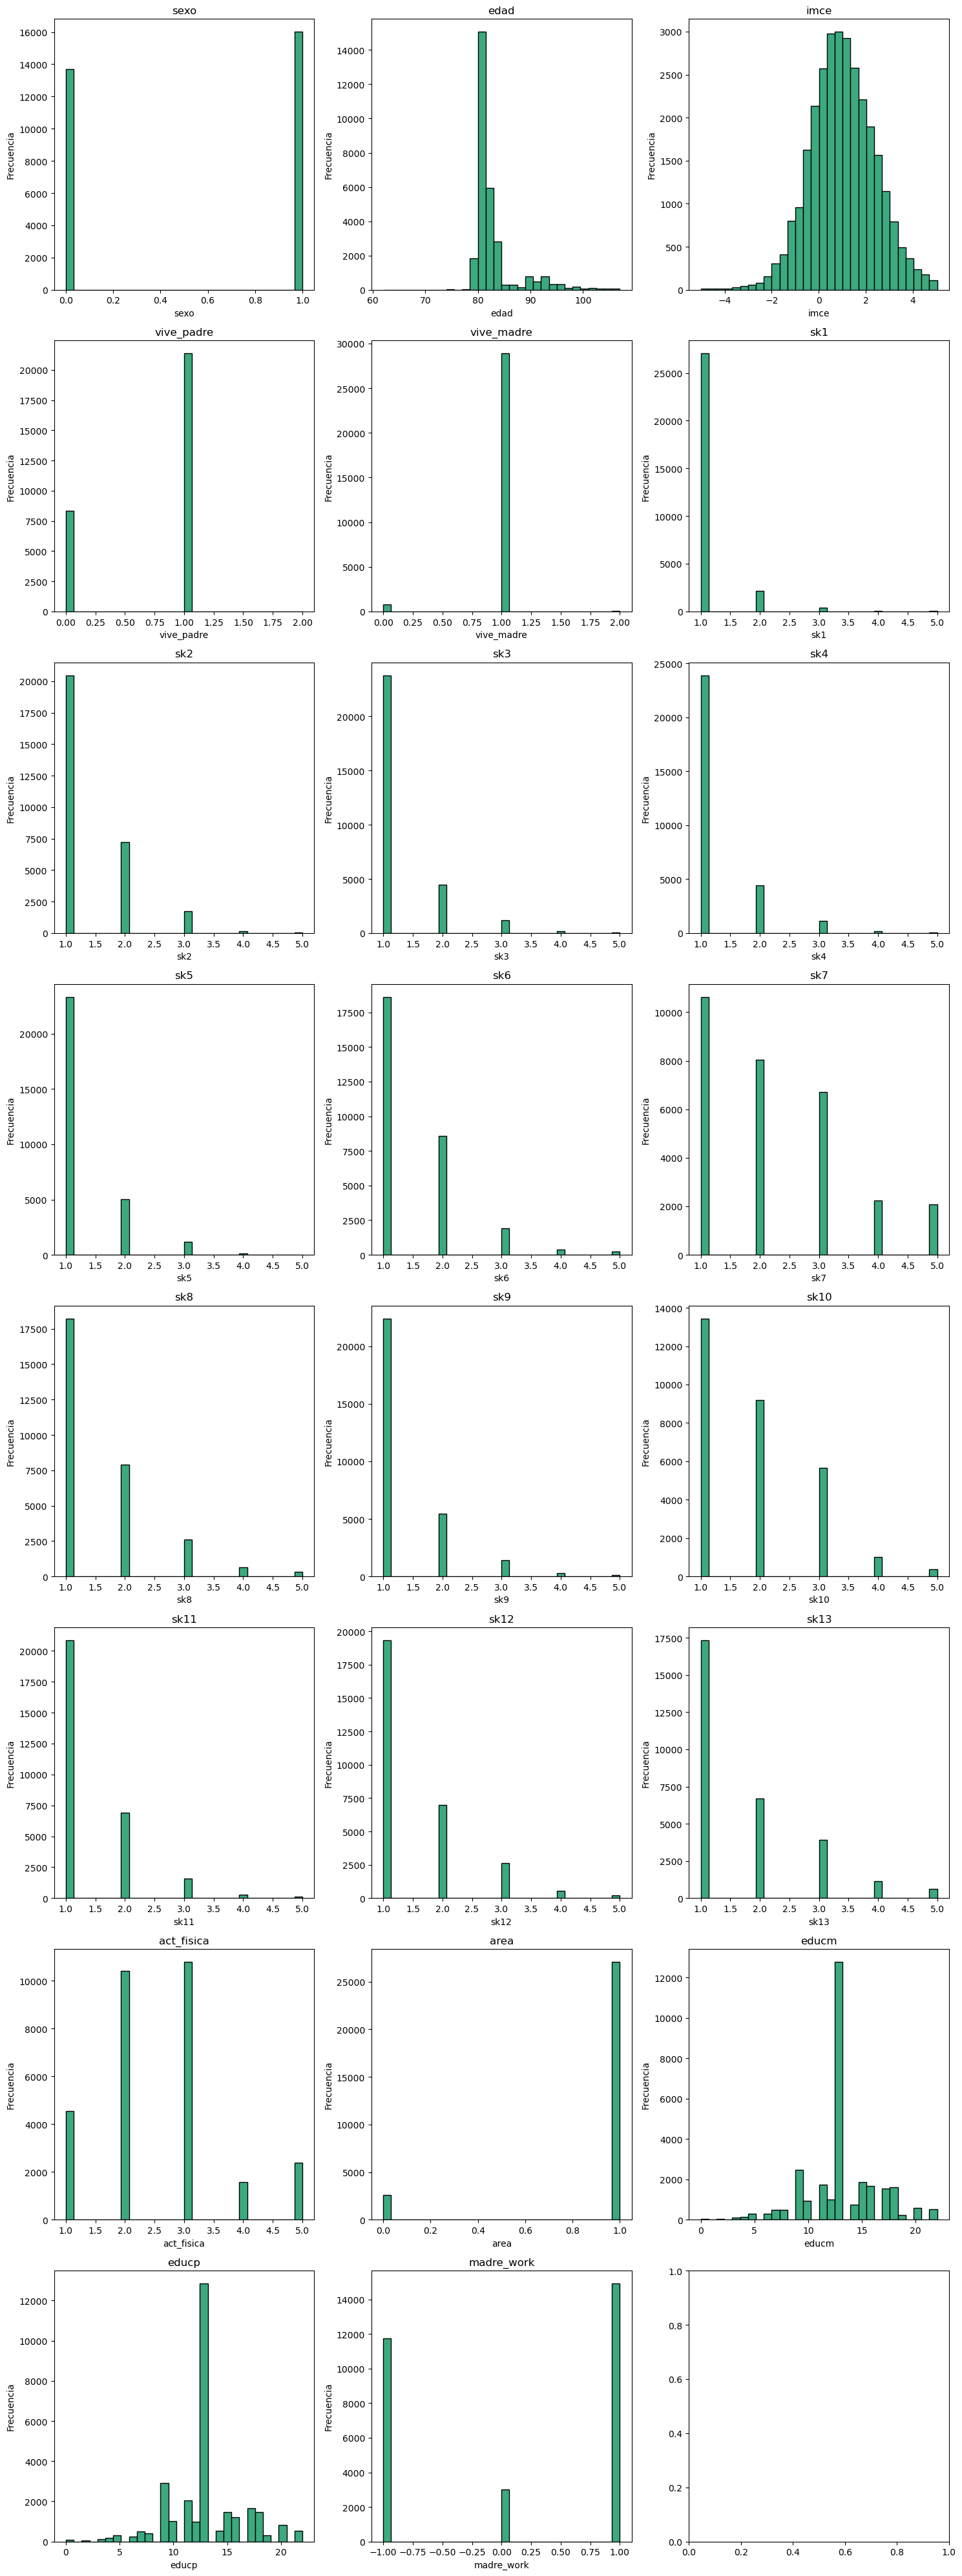

In [102]:
#Creamos gráficos de los valores de todas las variables
numerical_columns = df.select_dtypes(include='number').columns;
num_columns = len(numerical_columns);
fig, axs = plt.subplots((num_columns + 2) // 3, 3, figsize=(15, (num_columns + 2) // 3 * 5));
for i, column in enumerate(numerical_columns):
    ax = axs[i // 3, i % 3];
    ax.hist(df[column], bins=30, color='#3CA97E', edgecolor='black');
    ax.set_title(f'{column}');
    ax.set_xlabel(column);
    ax.set_ylabel('Frecuencia');
plt.tight_layout();
plt.show()

In [103]:
# Seleccionamos de variables sk1 a sk13
sk_vars = [col for col in df.columns if col.startswith("sk")]
df1 = df[sk_vars]



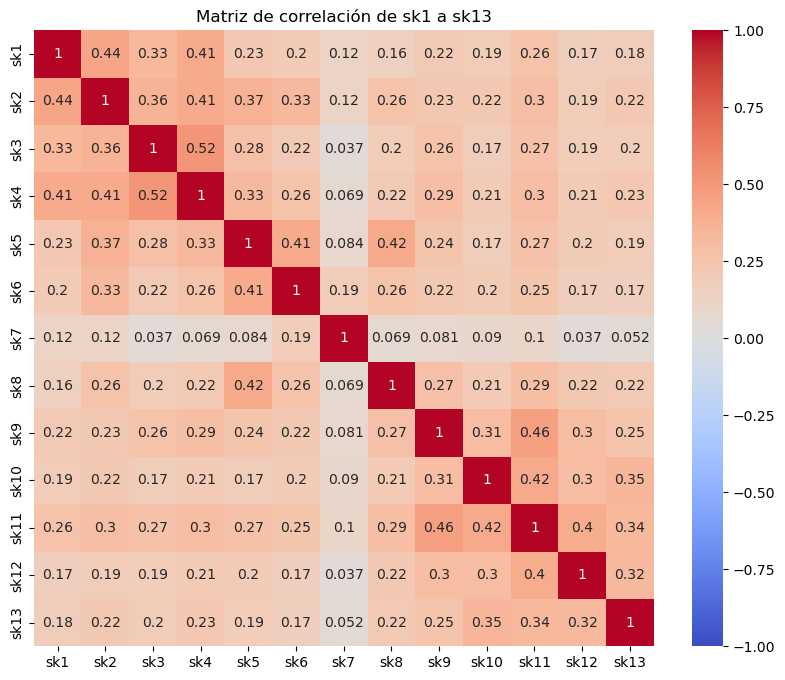

In [104]:

plt.figure(figsize=(10, 8))
sns.heatmap(df1.corr(), annot=True, cmap='coolwarm', vmin = - 1)
plt.title("Matriz de correlación de sk1 a sk13")
plt.show()

In [105]:
df2 = df.loc[:, 'sk1':'sk13']
df2 = df2.drop('sk7', axis=1)
#Eliminamos sk7 porque es muy agresivo.

2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

R: El análisis factorial exploratorio (EFA) permitió identificar una estructura de tres factores latentes que agrupan de manera lógica y coherente las variables socioemocionales evaluadas (sk1 a sk13). Esta solución fue respaldada tanto por el scree plot, y con tres autovalores superiores a 1.

Las comunalidades están entre 0.28 y 0.54, lo cual es aceptable, indicando que la mayoría de los ítems tienen una varianza moderadamente bien explicada por los factores comunes.


In [106]:
# Create factor analysis object and perform factor analysis
fa = FactorAnalyzer(rotation='varimax').fit(df2)

In [107]:
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.174841, 0.548195, 0.120534],
       [0.184364, 0.526839, 0.320694],
       [0.180408, 0.589673, 0.148862],
       [0.197244, 0.688252, 0.175895],
       [0.123231, 0.227225, 0.758978],
       [0.179168, 0.225624, 0.440862],
       [0.280362, 0.114328, 0.466153],
       [0.499531, 0.211997, 0.184684],
       [0.559231, 0.126959, 0.107675],
       [0.669339, 0.214191, 0.180514],
       [0.525805, 0.113139, 0.133111],
       [0.482427, 0.155489, 0.119697]])

In [108]:
fa.get_eigenvalues()

(array([4.003739, 1.347633, 1.089935, 0.802648, 0.743580, 0.706589,
        0.691043, 0.610450, 0.531272, 0.519068, 0.491722, 0.462321]),
 array([3.416238, 0.748787, 0.543888, 0.169035, 0.098914, 0.030284,
        0.006161, -0.007959, -0.042714, -0.062278, -0.082935, -0.108507]))

In [109]:
fa.get_communalities()

array([0.345616, 0.414394, 0.402421, 0.543535, 0.642865, 0.277366,
       0.308973, 0.328582, 0.340452, 0.526478, 0.306990, 0.271240])

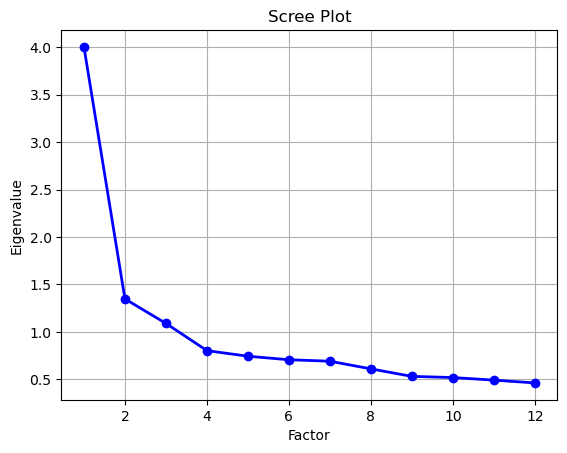

In [110]:
eigenvalues, _ = fa.get_eigenvalues()

# Crear scree plot
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()


In [111]:
fa.get_factor_variance()

(array([1.781394, 1.659008, 1.268511]),
 array([0.148450, 0.138251, 0.105709]),
 array([0.148450, 0.286700, 0.392409]))

In [112]:
print(semopy.efa.explore_cfa_model(df2, pval=0.05))

eta1 =~ sk11 + sk9 + sk10 + sk12
eta2 =~ sk4 + sk2 + sk11 + sk5 + sk3 + sk9 + sk1 + sk6 + sk8 + sk12
eta3 =~ sk11 + sk12 + sk13



3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

R: Se graficaron los factores obtenidos en el análisis factorial por pares, usando como caracterización las variables sexo, área, IMCE y actividad física.

Sexo:se ve una distribución homogénea tanto para hombres, como para mujeres.

Área: También se ve una distribución pajera entre rural y urbano.

IMCE: Se observa como los mismos tonos de morado se van agrupando un poco más.

Actividad Física: Se ve una predominancia de tonos más claros.


In [113]:
df = df.dropna().reset_index(drop=True)

# Obtenemos factor scores de EFA
factor_scores = fa.transform(df2)

# df con factores
factor_df = pd.DataFrame(factor_scores, columns=['Factor1', 'Factor2', 'Factor3'])

factor_df['sexo'] = df['sexo'].values
factor_df['area'] = df['area'].values
factor_df['imce'] = df['imce'].values
factor_df['act_fisica'] = df['act_fisica'].values



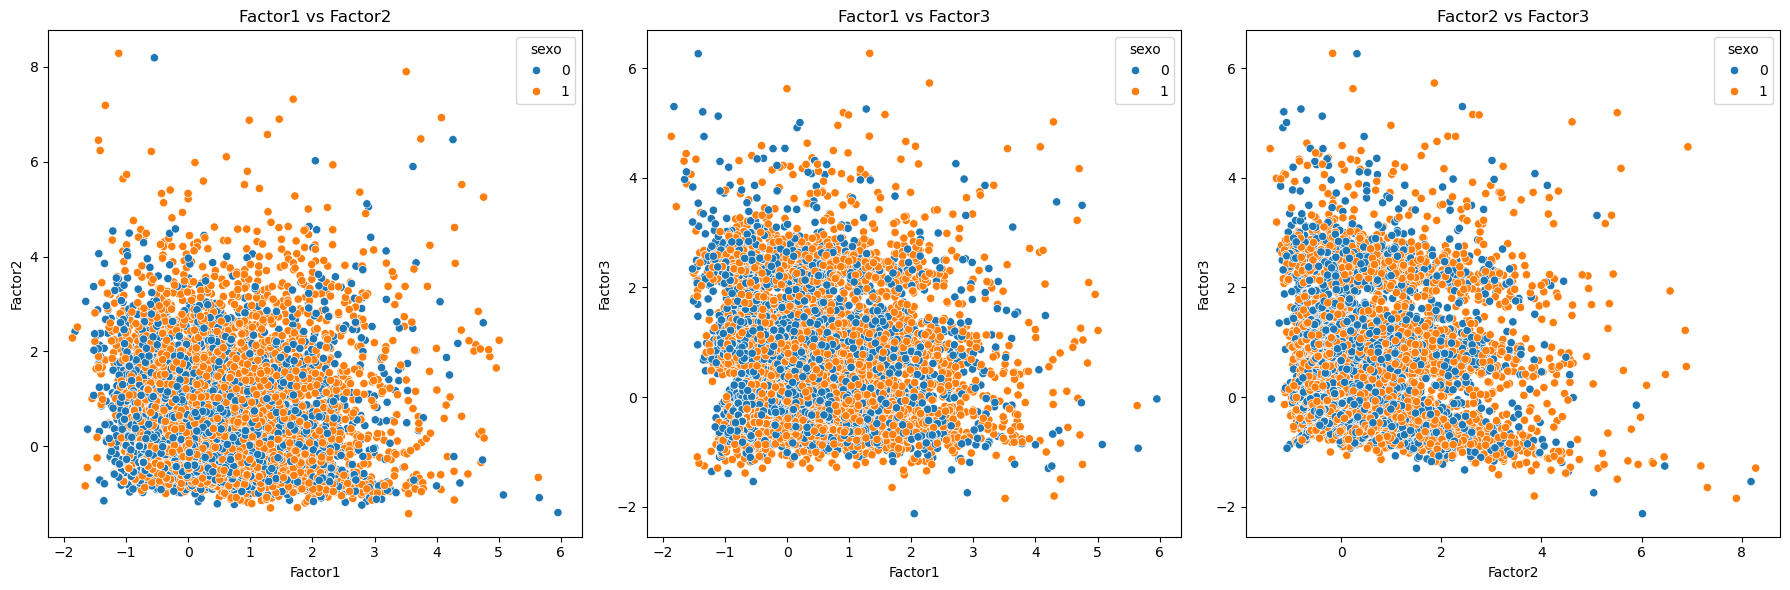

In [114]:
d = "sexo" 
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Factor1 vs Factor2
sns.scatterplot(data=factor_df, x='Factor1', y='Factor2', hue=d, ax=axs[0])
axs[0].set_title("Factor1 vs Factor2")
axs[0].set_xlabel("Factor1")
axs[0].set_ylabel("Factor2")

# Factor1 vs Factor3
sns.scatterplot(data=factor_df, x='Factor1', y='Factor3', hue=d, ax=axs[1])
axs[1].set_title("Factor1 vs Factor3")
axs[1].set_xlabel("Factor1")
axs[1].set_ylabel("Factor3")

# Factor2 vs Factor3
sns.scatterplot(data=factor_df, x='Factor2', y='Factor3', hue=d, ax=axs[2])
axs[2].set_title("Factor2 vs Factor3")
axs[2].set_xlabel("Factor2")
axs[2].set_ylabel("Factor3")

plt.tight_layout()
plt.show()

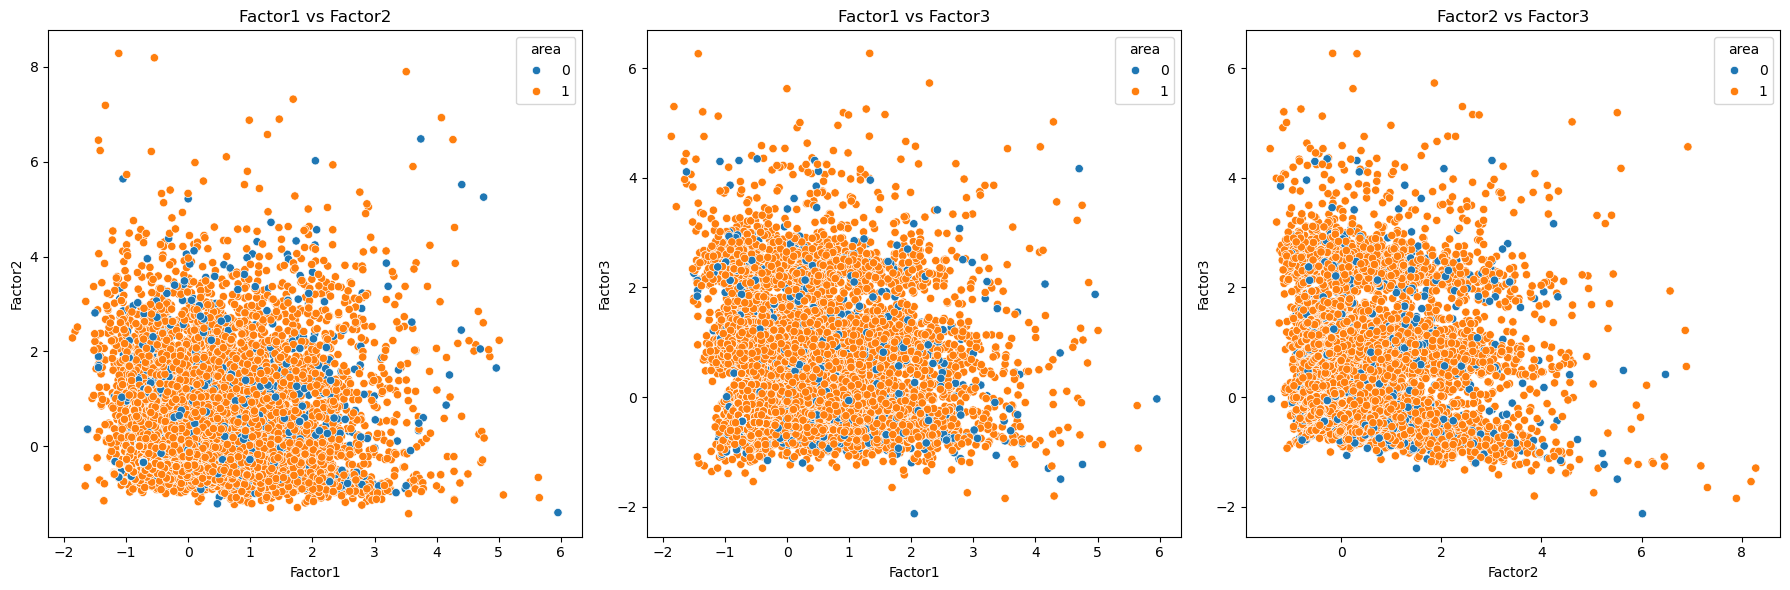

In [115]:
d = "area" 
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Factor1 vs Factor2
sns.scatterplot(data=factor_df, x='Factor1', y='Factor2', hue=d, ax=axs[0])
axs[0].set_title("Factor1 vs Factor2")
axs[0].set_xlabel("Factor1")
axs[0].set_ylabel("Factor2")

# Factor1 vs Factor3
sns.scatterplot(data=factor_df, x='Factor1', y='Factor3', hue=d, ax=axs[1])
axs[1].set_title("Factor1 vs Factor3")
axs[1].set_xlabel("Factor1")
axs[1].set_ylabel("Factor3")

# Factor2 vs Factor3
sns.scatterplot(data=factor_df, x='Factor2', y='Factor3', hue=d, ax=axs[2])
axs[2].set_title("Factor2 vs Factor3")
axs[2].set_xlabel("Factor2")
axs[2].set_ylabel("Factor3")

plt.tight_layout()
plt.show()

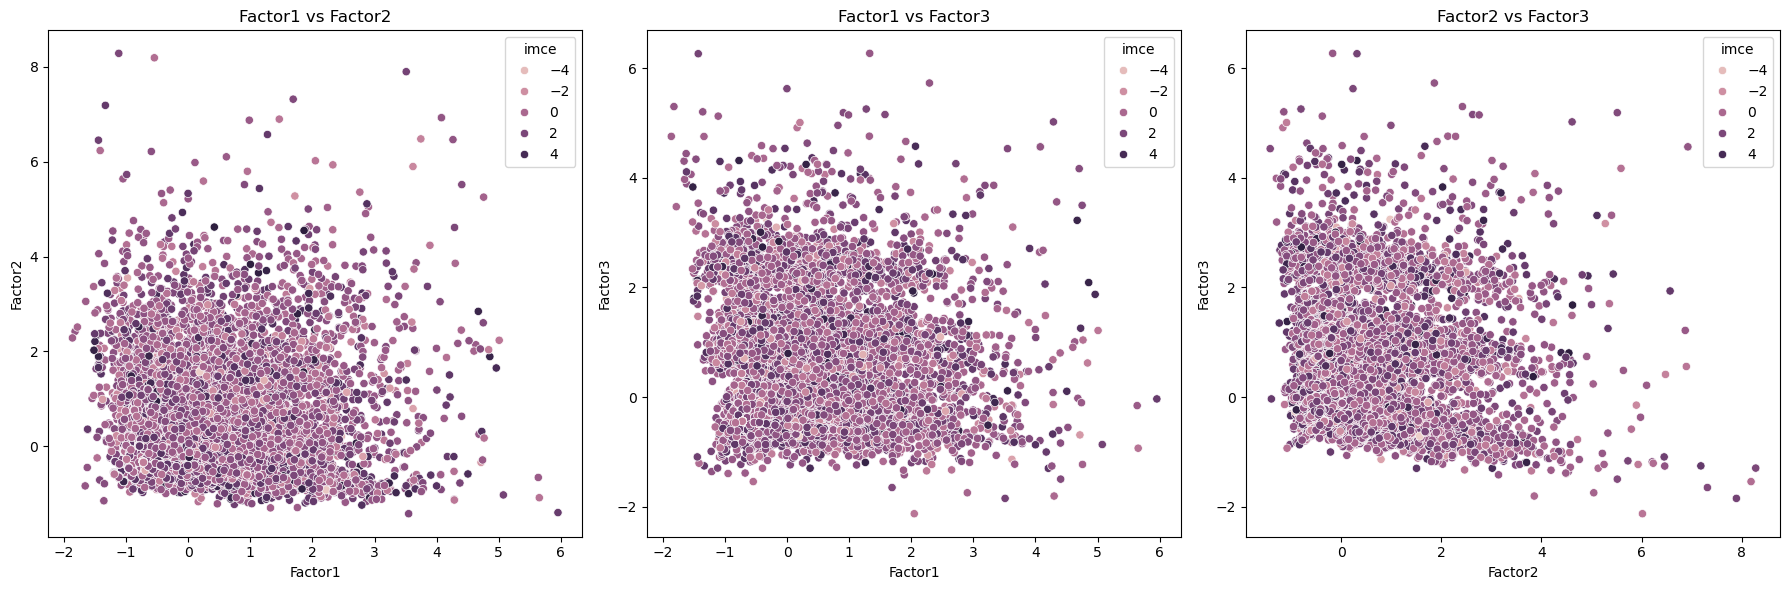

In [116]:
d = "imce"  
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Factor1 vs Factor2
sns.scatterplot(data=factor_df, x='Factor1', y='Factor2', hue=d, ax=axs[0])
axs[0].set_title("Factor1 vs Factor2")
axs[0].set_xlabel("Factor1")
axs[0].set_ylabel("Factor2")

# Factor1 vs Factor3
sns.scatterplot(data=factor_df, x='Factor1', y='Factor3', hue=d, ax=axs[1])
axs[1].set_title("Factor1 vs Factor3")
axs[1].set_xlabel("Factor1")
axs[1].set_ylabel("Factor3")

# Factor2 vs Factor3
sns.scatterplot(data=factor_df, x='Factor2', y='Factor3', hue=d, ax=axs[2])
axs[2].set_title("Factor2 vs Factor3")
axs[2].set_xlabel("Factor2")
axs[2].set_ylabel("Factor3")

plt.tight_layout()
plt.show()

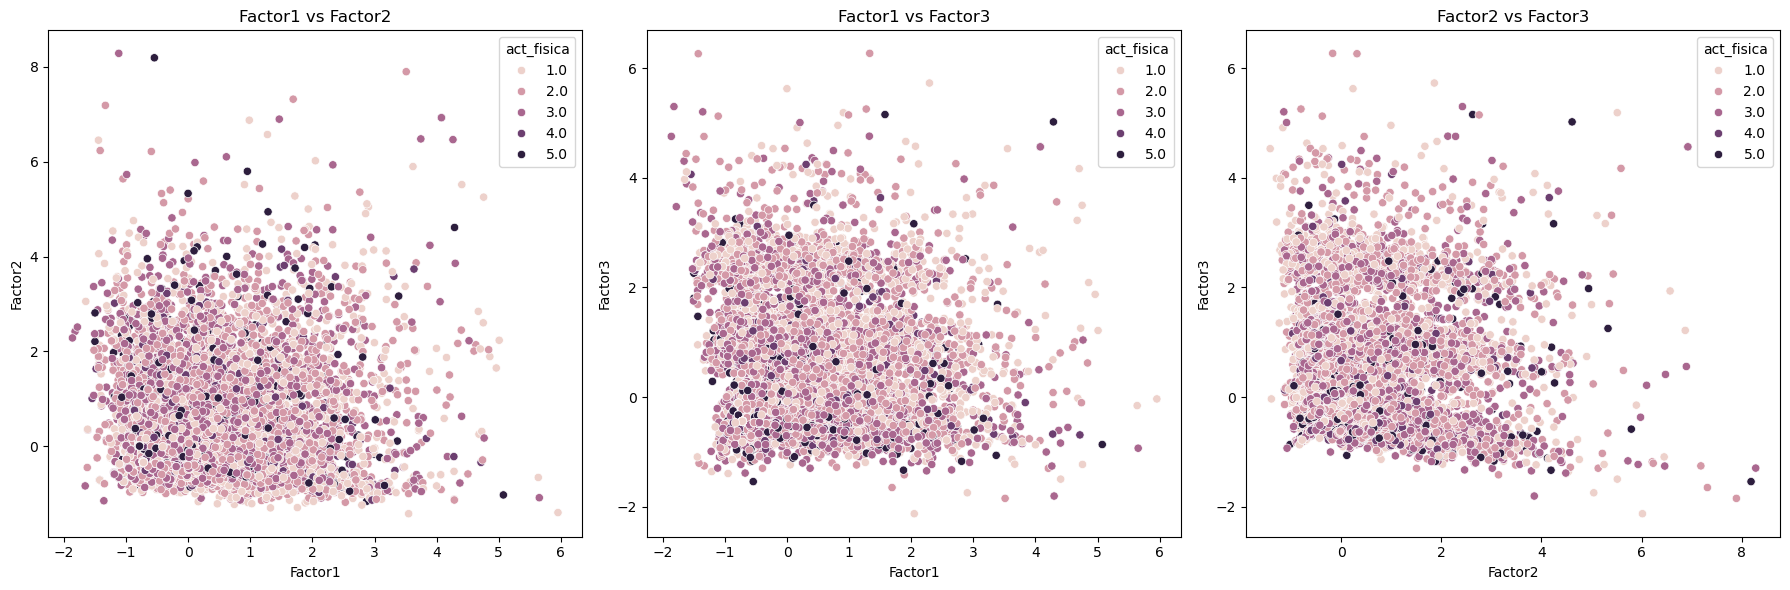

In [117]:
d = "act_fisica"  
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Factor1 vs Factor2
sns.scatterplot(data=factor_df, x='Factor1', y='Factor2', hue=d, ax=axs[0])
axs[0].set_title("Factor1 vs Factor2")
axs[0].set_xlabel("Factor1")
axs[0].set_ylabel("Factor2")

# Factor1 vs Factor3
sns.scatterplot(data=factor_df, x='Factor1', y='Factor3', hue=d, ax=axs[1])
axs[1].set_title("Factor1 vs Factor3")
axs[1].set_xlabel("Factor1")
axs[1].set_ylabel("Factor3")

# Factor2 vs Factor3
sns.scatterplot(data=factor_df, x='Factor2', y='Factor3', hue=d, ax=axs[2])
axs[2].set_title("Factor2 vs Factor3")
axs[2].set_xlabel("Factor2")
axs[2].set_ylabel("Factor3")

plt.tight_layout()
plt.show()


4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). 

R: El CFA confirma la estructura de 3 factores del EFA. Se modificaron los sk por eta, de acuerdo a los loadings de la pregunta 2, dejando las variables asociadas a solo un factor, en donde tenemos que  el eta 1 tiene los sk relacionados al lado emocional o artístico, el eta 2 a las habilidades sociales y el eta 3 a lac activiades compartidas.

Todas las variables mostraron cargas factoriales altas y significativas (p < 0.001), es decir, son buenos indicadores de los facores. 
Podemos decir que se presentó buen ajuste global con valores dentro de los esperados(CFI = 0.948, TLI = 0.933, RMSEA = 0.052), por lo que la estructura propuesta representa correctamente la relación entre las variables y los factores latentes.

In [118]:
mod = '''
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13 # Emocional/artístico
eta2 =~ sk1 + sk2 + sk3 + sk4            # Habilidades sociales
eta3 =~ sk5 + sk6 + sk8                  # Cooperación/juegos compartidos

'''

model = semopy.Model(mod);
out = model.fit(df2);
print(out);

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.143
Number of iterations: 41
Params: 1.348 1.248 1.097 1.274 1.877 1.646 1.846 1.020 1.158 0.152 0.051 0.091 0.049 0.161 0.057 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.372 0.469 0.277


In [119]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4252.869542,0.0,80903.16637,0.948021,0.947433,0.931972,0.947433,0.932733,0.052674,53.713573,277.780299,0.143214


In [120]:
model.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,eta1,1.000000,0.594425,-,-,-
1,sk10,~,eta1,1.348296,0.562596,0.01854,72.725071,0.0
2,sk11,~,eta1,1.247906,0.736003,0.014736,84.684717,0.0
3,sk12,~,eta1,1.097330,0.540702,0.015523,70.692694,0.0
4,sk13,~,eta1,1.273586,0.506374,0.018913,67.339241,0.0
5,sk1,~,eta2,1.000000,0.582652,-,-,-
6,sk2,~,eta2,1.876642,0.644548,0.023793,78.87212,0.0
7,sk3,~,eta2,1.646084,0.631816,0.021121,77.934883,0.0
8,sk4,~,eta2,1.845637,0.715782,0.022169,83.253688,0.0
9,sk5,~,eta3,1.000000,0.718118,-,-,-


5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

R: El modelo StepMix con 4 clases latentes fue seleccionado como óptimo según el criterio SABIC (versión ajustada de BIC), demostrado en el gráfico. Las clases identificadas presentan diferencias evidentes en los valores promedio de IMCE, lo que confirma que el conjunto es válido. Además, el scatterplot muestra la separación de los grupos latentes, con subgrupos que presentan perfiles de edad e IMCE esperados.
Finalmente, los resultados nos dicen que la segmentación por clases latentes entrega información útil para diferenciar patrones nutricionales que influyen en el indice de masa corporal dentro de los estudiantes.

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.06it/s, max_LL=-5.18e+4, max_avg_LL=-1.74]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:04<00:00,  4.06s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]


Fitting StepMix...


...

Initializations (n_init) : 100%|██████████| 1/1 [00:08<00:00,  8.85s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:11<00:00, 11.04s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:12<00:00, 12.17s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


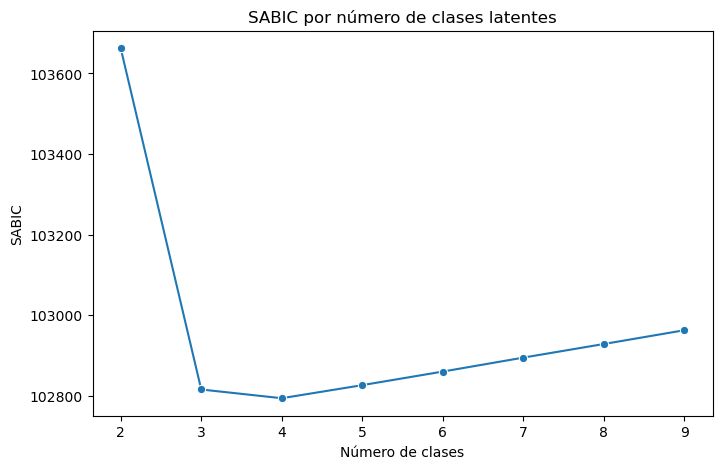

In [121]:
# dataframe con solo imce
df_step = df[['imce']].dropna().reset_index(drop=True)

K = range(2, 10)
fits = []
bic_scores = []

for k in K:
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123)
    model.fit(df_step)
    fits.append(model)
    bic_scores.append(model.sabic(df_step))  

# Graficar el BIC para ver el óptimo
plt.figure(figsize=(8, 5))
sns.lineplot(x=K, y=bic_scores, marker='o')
plt.title("SABIC por número de clases latentes")
plt.xlabel("Número de clases")
plt.ylabel("SABIC")
plt.show()



In [122]:
# Ajustar modelo con k=4 
model = StepMix(n_components=4, measurement="gaussian", verbose=1, random_state=123)
model.fit(df_step)

# Predecir clase latente
df_step['cluster'] = model.predict(df_step)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:05<00:00,  5.62s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                        
          class_no                   0       1       2       3
          param variable                                      
          means imce             1.173  2.7111 -2.5822  0.1384
    Class weights
        Class 1 : 0.49
        Class 2 : 0.16
        Class 3 : 0.01
        Class 4 : 0.35
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 4
    Number of estimated parameters: 7
    Log-likelihood (LL)           : -51336.0764
    -2LL                          : 102672.1527
    Average LL                    : -1.7287
    AIC                           : 102686.15
    BIC                           : 102744.24
    CAIC                          : 102751.24
    Sample-Size Adjusted BIC      : 102794.09
    Entropy                       : 22265.7966
    Scaled Relative Entropy    

In [123]:
df_step[['act_fisica', 'edad']] = df[['act_fisica', 'edad']].reset_index(drop=True)


In [124]:
model = StepMix(n_components=4, measurement="gaussian", verbose=1, random_state=123)


model.fit(df_step)
df_step['cluster']=model.predict(df_step)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.51it/s, max_LL=-2.06e+5, max_avg_LL=-6.94]

MODEL REPORT
    Measurement model parameters
          model_name       gaussian_unit                           
          class_no                     0        1        2        3
          param variable                                           
          means act_fisica        2.5720   2.5328   2.4721   2.5562
                cluster           2.9642   1.0569   0.9887   0.1742
                edad             81.1214  91.3917  99.9321  81.1412
                imce             -0.5012   1.0216   0.9807   1.6853
    Class weights
        Class 1 : 0.27
        Class 2 : 0.09
        Class 3 : 0.02
        Class 4 : 0.61
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 4
    Number of estimated parameters: 19
    Log-likelihood (LL)           : -205975.5400
    -2LL                          : 411951.0800
    Average LL                    : -6.9361
    AIC                           : 

In [125]:
df_step.groupby('cluster')[['imce', 'act_fisica', 'edad']].mean()


,imce,act_fisica,edad
cluster,,,
0,-0.503106,2.571714,81.120834
1,1.021797,2.533381,91.349693
2,0.980124,2.472452,99.797521
3,1.689337,2.556301,81.141302


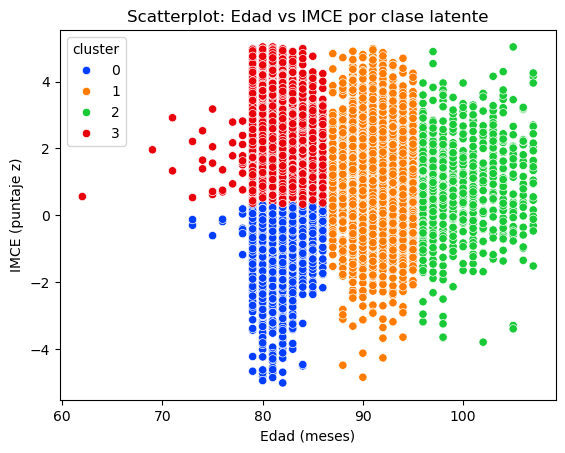

In [126]:
sns.scatterplot(data=df_step, x='edad', y='imce', hue='cluster', palette='bright')
plt.title("Scatterplot: Edad vs IMCE por clase latente")
plt.xlabel("Edad (meses)")
plt.ylabel("IMCE (puntaje z)")
plt.show()


6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

R: El modelo SEM mostró buen ajuste (CFI = 0.93, TLI = 0.91, RMSEA = 0.046), mostrando  que la estructura propuesta explica correctamente el IMCE. Los tres factores latentes (emocional/artístico, habilidades sociales y cooperación/jurgo compartido) influyen significativamente en el IMCE, al igual que sexo, área y actividad física. El seox se relaciona positivamente al IMCE, mietras que area y actividad fisica de forma negativa  
En resumen, el modelo respalda la relevancia de factores sociales y emocionales en el indice de masa corporal de los estudiantes.

In [127]:

mod = """
F1 =~ sk9 + sk10 + sk11 + sk12 + sk13
F2 =~ sk1 + sk2 + sk3 + sk4
F3 =~ sk5 + sk6 + sk8
"""

model = semopy.Model(mod)
out=model.fit(df1)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.143
Number of iterations: 41
Params: 1.348 1.248 1.097 1.274 1.877 1.646 1.846 1.020 1.158 0.152 0.049 0.051 0.057 0.161 0.091 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.372 0.469 0.277


In [128]:
model.inspect(mode='list', what="names", std_est=True)
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4252.869542,0.0,80903.16637,0.948021,0.947433,0.931972,0.947433,0.932733,0.052674,53.713573,277.780299,0.143214


In [129]:
cfa1=model.predict_factors(df1)
cfa1.describe()

,F1,F2,F3
count,2.969600e+04,2.969600e+04,2.969600e+04
mean,5.359697e-17,-3.924064e-17,1.765829e-16
std,3.429805e-01,1.952537e-01,3.410501e-01
min,-3.281671e-01,-1.457395e-01,-2.948087e-01
25%,-2.511554e-01,-1.311468e-01,-2.592921e-01
50%,-1.060254e-01,-7.912374e-02,-1.201227e-01
75%,1.668930e-01,5.826194e-02,1.442635e-01
max,2.706217e+00,1.933968e+00,2.995333e+00


In [130]:
mod_cf = '''
#Measurement
eta1 =~ sk11 + sk9 + sk10 + sk12          
eta2 =~ sk6 + sk8 + sk5                   
eta3 =~ sk4 + sk2 + sk3 + sk1               

#Structural
imce ~ eta1 + eta2 + eta3 + sexo + area + act_fisica
'''

model_cfa = semopy.Model(mod_cf);
out = model_cfa.fit(df);
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.193
Number of iterations: 41
Params: 0.795 1.004 0.825 1.134 0.983 1.016 0.893 0.542 -0.035 0.236 -0.157 0.133 -0.153 -0.026 0.251 0.118 0.120 0.167 0.166 0.108 1.865 0.095 0.618 0.185 0.454 0.242 0.199 0.158 0.150 0.373 0.470 0.270


In [131]:
semopy.calc_stats(model_cfa)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,88,108,5717.232435,0.0,76422.02719,0.926236,0.925189,0.908186,0.925189,0.909471,0.046413,63.614949,329.175514,0.192525


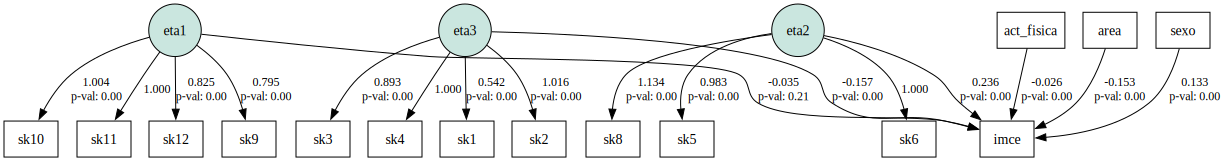

In [132]:

model_cfa.inspect(mode='list', what="names", std_est=True)
semopy.semplot(model_cfa, "semmodel.png")

7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?  

R: Se hizo el modelo sem por separado en cada clase latente. LLegamos a que aunque el modelo logró ajustarse a los grupos, los índices de ajuste fueron bajos, por lo que no mejora al estimarlo por subgrupos. No se justiifca modelar por clases, el modelo general da un mejore ajuste.


In [ ]:
mod = """
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13
eta2 =~ sk1 + sk2 + sk3 + sk4
eta3 =~ sk5 + sk6 + sk8
imce ~ eta1 + eta2 + eta3 + act_fisica + edad + sexo
"""

resultados_por_cluster = {}

for grupo in sorted(df_step['cluster'].unique()):
    print(f"\n Analizando cluster {grupo}")
    
    
    df_cluster = df.copy()
    df_cluster['cluster'] = df_step['cluster']
    df_cluster = df_cluster[df_cluster['cluster'] == grupo].dropna()

    
    model = ModelMeans(mod)
    model.fit(df_cluster)

    stats = calc_stats(model)
    resultados_por_cluster[grupo] = stats
    print(stats.T)



 Analizando cluster 0
                      Value
DoF            4.400000e+01
DoF Baseline   6.500000e+01
chi2           7.951848e-07
chi2 p-value   1.000000e+00
chi2 Baseline  5.353793e+00
CFI            2.623169e-01
GFI            9.999999e-01
AGFI           9.999998e-01
NFI            9.999999e-01
TLI           -8.975914e-02
RMSEA          0.000000e+00
AIC            9.244813e+01
BIC            4.209110e+02
LogLik         7.759346e-01

 Analizando cluster 1
                    Value
DoF             44.000000
DoF Baseline    65.000000
chi2             5.529226
chi2 p-value     1.000000
chi2 Baseline    8.834008
CFI              0.315052
GFI              0.374098
AGFI             0.075371
NFI              0.374098
TLI             -0.011855
RMSEA            0.000000
AIC             93.628484
BIC            372.195771
LogLik           0.185758

 Analizando cluster 2
                    Value
DoF             44.000000
DoF Baseline    65.000000
chi2             7.951203
chi2 p-value     